<a href="https://colab.research.google.com/github/Sahro2266/Breast-cancer-/blob/main/Copy_of_Project_5%266_X_Ray_Images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 5&6: X-Ray Images

Use this notebook as the starting point for the Practice activities.

In this notebook we will apply CNNs to the Chest X-Ray Images (Pneumonia) image database. The original Kaggle dataset has over 5,800 images and requires over 1 GB of space, so we will be using a subset of these images.

## Prep 1: Make you own copy of this notebook

Under the **File** menu select **Save a copy in Drive**. This will save your copy of the notebook to the special *Colab Notebooks* fold in your Google drive.

## Prep 2: Student Name: **Sahro Elmi**

Adding your name to the notebook makes it grading easier. Please take a second an put your name in each of your notebooks.

## Prep 3: Writeup

Make a copy of the [ Project 5&6 Writeup](https://docs.google.com/document/d/18w63LifLMnjBl0hMLsKPXO5oO92aG5H6ETK0tJP6IHw/edit?usp=sharing) use it to format the writeup of your experiment.

You will submit a link to the Writeup to Brightspace late.

### My Writeup Link:

https://docs.google.com/document/d/1JWroZrQB-fDiUCJZDod6hin9oPirIgu0S-FBwPhERow/edit?tab=t.0#heading=h.c5i5uvs9agmm

​




# Section 0: Set up libraries and training data

=== *You must run this section to set up things for any of the sections below * ===
### Setting up Python tools



We'll use three libraries for this tutorial:
- [pandas](http://pandas.pydata.org/) : dataframes for spreadsheet-like data analysis, reading CSV files, time series
- [numpy](http://www.numpy.org/) : for multidimensional data and linear algebra tools
- [matplotlib](http://matplotlib.org/) : Simple plotting and graphing
- [seaborn](http://stanford.edu/~mwaskom/software/seaborn/) : more advanced graphing
-  [scikit-learn](https://scikit-learn.org/stable/) : provides many machine learning algorithms and tools to training and test.




In [14]:
# We will turn off some warns in this notebook to make it easier to read for new students
import warnings
warnings.filterwarnings('ignore')

# First, we'll import pandas and numpy, two data processing libraries
import pandas as pd
import numpy as np

# We'll also import seaborn and matplot, twp Python graphing libraries
import seaborn as sns
import matplotlib.pyplot as plt
# Import the needed sklearn libraries
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

# The Keras library provides support for neural networks and deep learning
import tensorflow as tf
import tensorflow.keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout2D, Activation, Lambda, Flatten, LSTM
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam, RMSprop
#from tensorflow.keras.utils import np_utils
from tensorflow.keras import utils

print ("Libraries Imported")



Libraries Imported



This unit expands on the Convolutional Neural Network (CNN) models by looking at different architectures for CNNs

## Chest X-Ray Images (Pneumonia)

In this notebook we will apply CNNs to the [Chest X-Ray Images (Pneumonia) image database](https://www.kaggle.com/paultimothymooney/chest-xray-pneumonia). The original Kaggle dataset has over 5,800 images and requires over 1 GB of space, so we will be using a subset of these images.

<table>
<tbody>
<tr>
<td colspan="3" align="center"> <h2>
Chest X-rays showing Pnuemonia
</h2>
</td>
</tr>
<tr>
<td> <img src="https://github.com/CIS3115-Machine-Learning-Scholastica/CIS3315ML-xray_images/blob/main/train%20-%20small/PNEUMONIA/person104_virus_191.jpeg?raw=true" alt="Dice" style="height: 250px;"> </td>
<td> <img src="https://github.com/CIS3115-Machine-Learning-Scholastica/CIS3315ML-xray_images/blob/main/train%20-%20small/PNEUMONIA/person109_virus_203.jpeg?raw=true" alt="Duck" style="height: 250px;"> </td>
<td> <img src="https://github.com/CIS3115-Machine-Learning-Scholastica/CIS3315ML-xray_images/blob/main/train%20-%20small/PNEUMONIA/person115_virus_218.jpeg?raw=true" alt="Dog" style="width: 177px; height: 247px;"> </td>
</tr>
<tr>
<td colspan="3" align="center"> <h2>
Chest X-rays without Pnuemonia
</h2>
</td>
</tr>
<tr>
<td> <img src="https://raw.githubusercontent.com/CIS3115-Machine-Learning-Scholastica/CIS3315ML-xray_images/main/train%20-%20small/NORMAL/IM-0125-0001.jpeg" alt="Dice" style="height: 250px;"> </td>
<td> <img src="https://raw.githubusercontent.com/CIS3115-Machine-Learning-Scholastica/CIS3315ML-xray_images/main/train%20-%20small/NORMAL/IM-0141-0001.jpeg" alt="Duck" style="height: 250px;"> </td>
<td> <img src="https://raw.githubusercontent.com/CIS3115-Machine-Learning-Scholastica/CIS3315ML-xray_images/main/train%20-%20small/NORMAL/IM-0151-0001.jpeg" alt="Dog" style="width: 177px; height: 247px;"> </td>
</tr>
</tbody>
</table>


## Read  the data from Github

If you are using Google's Colab, you need to copy the images from GitHub. This may take a couple minutes.

Check the left panel and you should see a folder called CIS3115-data created under the Files tab.

In [15]:
!rm -rf /content/CIS3115-data
!git clone https://github.com/CIS3115-Machine-Learning-Scholastica/CIS3315ML-xray_images CIS3115-data

Cloning into 'CIS3115-data'...
remote: Enumerating objects: 2304, done.
remote: Total 2304 (delta 0), reused 0 (delta 0), pack-reused 2304 (from 1)
Receiving objects: 100% (2304/2304), 350.88 MiB | 22.25 MiB/s, done.
Resolving deltas: 100% (2/2), done.
Updating files: 100% (2306/2306), done.


## Display sample images

Here the images of two of the catagories in the database.



Images of Normal lungs


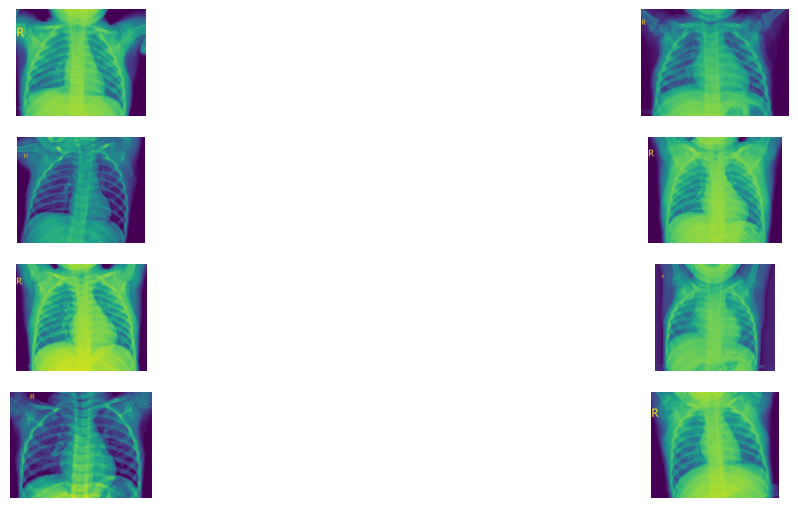

In [16]:
from glob import glob
from PIL import Image

def plot_images(imgs, rows=5):
    # Set figure to 15 inches x 8 inches
    figure = plt.figure(figsize=(15, 8))
    cols = len(imgs) // rows + 1
    for i in range(len(imgs)):
        subplot = figure.add_subplot(rows, cols, i + 1)
        subplot.axis('Off')
        plt.imshow(imgs[i])

def plot_images_for_filenames(filenames, rows=5):
    imgs = [plt.imread(f'{filename}') for filename in filenames]
    return plot_images(imgs, rows)

sample_images = glob("/content/CIS3115-data/val/NORMAL/*.jpeg")
print ("Images of Normal lungs")
plot_images_for_filenames(sample_images)




Images of Lungs with Pneumonia


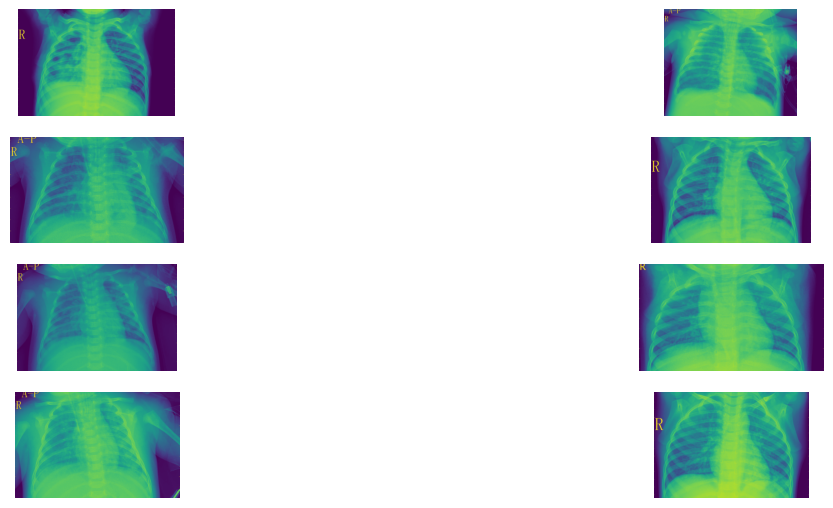

In [17]:
sample_images2 = glob("/content/CIS3115-data/val/PNEUMONIA/*.jpeg")
print ("Images of Lungs with Pneumonia")
plot_images_for_filenames(sample_images2)

## Set up callbacks for training

*You do not need to change this code.*

- learning_rate_reduction: This reduces the [Learning Rate](https://towardsdatascience.com/understanding-learning-rates-and-how-it-improves-performance-in-deep-learning-d0d4059c1c10)
 during training.
- early_stops: [EarlyStopping](https://keras.io/callbacks/#earlystopping) stops the training if the model is not learning is not improving.
- checkpointer: [ModelCheckpoint](https://keras.io/callbacks/#modelcheckpoint) saves best weights of the model.

In [18]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

learning_rate_reduction = ReduceLROnPlateau(monitor='loss',
                                            patience=5,
                                            verbose=2,
                                            factor=0.5,
                                            min_lr=0.000001)

early_stops = EarlyStopping(monitor='loss',
                            min_delta=0,
                            patience=6,
                            verbose=2,
                            mode='auto')

checkpointer = ModelCheckpoint(filepath = 'cis3115_best.weights.h5',
                               verbose=2,
                               save_best_only=True,
                               save_weights_only = True)


## Image Handling

Define the folders where the images are stored and set up image generators to read the images in.

Keras has a method called  [flow_from_directory()](https://keras.io/preprocessing/image/#flow_from_directory) defined for an ImageDataGenerator. It expects a folder with sub-folders. Each sub-folder is named for the category of item to be identified and is filled with photos of that object.

- train_generator: Reads images from the training folder and resizes them if needed.
- test_generator: Reads images from the test folder and resizes them if needed.

## Image Size

This is where the images are resized. Set IMAGE_SIZE to the size you want to use. The default is:

`IMAGE_SIZE = (512, 512)`

In [19]:
# Read data from the folders

IMAGE_SIZE = (512, 512)

validate_folder = '/content/CIS3115-data/test'
train_folder = '/content/CIS3115-data/train - small'

print ("Reading training images from: " ,train_folder)
print ("Reading validation images from: " ,validate_folder)

# this is the augmentation configuration we will use for training
train_datagen = ImageDataGenerator(
#        rotation_range=10,
#        width_shift_range=0.1,
#        height_shift_range=0.1,
        rescale=1./255,
#        shear_range=0.1,
#        zoom_range=0.1,
        horizontal_flip=True)

# this is the augmentation configuration we will use for testing:
# only rescaling
test_datagen = ImageDataGenerator(rescale=1./255)

batch_size = 8
#batch_size = 32              # This performs better but might take too much memory

# this is a generator that will read pictures found in
# subfolers of 'data/train', and indefinitely generate
# batches of augmented image data
print ("===== Setting up training image generator")
train_generator = train_datagen.flow_from_directory(
        train_folder,  # this is the target directory
        target_size=IMAGE_SIZE,  # all images will be resized to 150x150
        batch_size=batch_size,
        color_mode="rgb",
        class_mode='categorical')  # since we use binary_crossentropy loss, we need binary labels

# this is a similar generator, for validation data
print ("===== Setting up test image generator")
validation_generator = test_datagen.flow_from_directory(
        validate_folder,
        target_size=IMAGE_SIZE,
        batch_size=batch_size,
        color_mode="rgb",
        class_mode='categorical')

# We will display the loss and the accuracy of the model for each epoch
# NOTE: this is a little fancier display than is shown in the textbook
def display_training_curves(training, validation, title, subplot):
    if subplot%10==1: # set up the subplots on the first call
        plt.subplots(figsize=(10,10), facecolor='#F0F0F0')
        plt.tight_layout()
    ax = plt.subplot(subplot)
    ax.set_facecolor('#F8F8F8')
    ax.plot(training)
    ax.plot(validation)
    ax.set_title('model '+ title)
    ax.set_ylabel(title)
    #ax.set_ylim(0.28,1.05)
    ax.set_xlabel('epoch')
    ax.legend(['train', 'valid.'])

Reading training images from:  /content/CIS3115-data/train - small
Reading validation images from:  /content/CIS3115-data/test
===== Setting up training image generator
Found 1662 images belonging to 2 classes.
===== Setting up test image generator
Found 624 images belonging to 2 classes.


# Section 1: Setup and train your CNN




## CNN Layers

For an overview of CNNs, see [MIT 6.S191: Convolutional Neural Networks](https://youtu.be/H-HVZJ7kGI0?t=1132). While the entire video is good, the key description of CNN layers starts at 19:00.

We will use the following Keras pre-built layers to build our CNN.

- **Conv2D**(16, (3, 3), activation='relu')
 - 16 filters, each one 3x3 pixels with default stride of 1
- **MaxPooling2D**(pool_size=(2, 2))
 - 2x2 max pooling filter with default stride of 2
- **Dropout**(0.25)
 - Randomly ignore 25% of the connections in a normal layer
- **SpatialDropout2D**(0.25)
 - Randomly ignore 25% of the connections in a CNN layer
- **Flatten**()
 - Convert a 2D layer into a 1D layer
- **Dense**(32, activation='relu')
 - Standard fully connected layer we have used before

## CNN Architectures

Researcher continue to develop CNN architectures.  These models have then been extensively trained with different datasets and their weights saved. Training allows the models to develop kernel filters that are applicable to other problems.

Read one of these articles that describe some of these architectures:
- [Architecture comparison of AlexNet, VGGNet, ResNet, Inception, DenseNet](https://towardsdatascience.com/architecture-comparison-of-alexnet-vggnet-resnet-inception-densenet-beb8b116866d) by Khush Patel, March 8, 2020
- [Top 4 Pre-Trained Models for Image Classification with Python Code](https://www.analyticsvidhya.com/blog/2020/08/top-4-pre-trained-models-for-image-classification-with-python-code/) by Purva Huilgol, August 18, 2020

## Select a pre-trained CNN model

Keras has a number of [pre-built CNN models](https://www.tensorflow.org/api_docs/python/tf/keras/applications).  You must select one of the architectures, learn more about it, and then use it on our images.
- densenet module: DenseNet models
- efficientnet module: EfficientNet models
- inception_resnet_v2 module: Inception-ResNet V2 model
- inception_v3 module: Inception V3 model
- mobilenet module: MobileNet v1 models
- mobilenet_v2 module: MobileNet v2 models
- mobilenet_v3 module: MobileNet v3 models
- resnet module: ResNet models
- resnet_v2 module: ResNet v2 models
- vgg16 module: VGG16 model
- vgg19 module: VGG19 model
- xception module: Xception V1 model

In [24]:
# Set up the Neural Network
OUTPUT_SIZE = 2

# ========== Custom CNN - Run 2 (With Dropout) ==========
model = Sequential()
model.add(Conv2D(8, kernel_size=(3, 3), activation='relu', input_shape=[*IMAGE_SIZE, 3]))
model.add(Conv2D(8, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Conv2D(16, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(OUTPUT_SIZE, activation='softmax'))

print("Final model created:")
model.summary()

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Final model created:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 510, 510, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 508, 508, 8)    │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 254, 254, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 254, 254, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 252, 252, 16)   │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 126, 126, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 126, 126, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 124, 124, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 123008)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │    31,490,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,497,434 (120.15 MB)

 Trainable params: 31,497,434 (120.15 MB)

 Non-trainable params: 0 (0.00 B)

## Train the Neural Network

There are 1,662 training images and 624 validation testing images.
- train_generator: The image generator defined above that pulls images from the training folder for each catagory
- steps_per_epoch=100: Number of image batches to process per epoch. Our batch size is 8, so the network will train on 800 images in each epoch.
- epochs=50: Number of epochs to train.
- learning_rate_reduction: Reduce the learning rate if loss does not keep dropping
- early_stops: Stop if loss does not keep dropping
- validation_generator: The image generator to use for validation, no rotations or shifting
- validation_steps: Number of image batches to use during validation.



In [25]:
# Train the model with the images in the folders
history = model.fit(
        train_generator,
        steps_per_epoch=100,                     # Number of images to process per epoch
        epochs=50,                              # Number of epochs
        callbacks=[learning_rate_reduction, early_stops],
        validation_data=validation_generator,
        validation_steps=20                     # Number of images from validation set to test
        )

print ("Final training accuracy = ",history.history['accuracy'][-1])
print ("Final testing accuracy = ",history.history['val_accuracy'][-1])

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 131ms/step - accuracy: 0.7875 - loss: 0.8409 - val_accuracy: 0.6687 - val_loss: 0.5928 - learning_rate: 0.0010
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 164ms/step - accuracy: 0.8509 - loss: 0.3356 - val_accuracy: 0.7250 - val_loss: 0.4830 - learning_rate: 0.0010
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8906 - loss: 0.2886 - val_accuracy: 0.7437 - val_loss: 0.5508 - learning_rate: 0.0010
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - accuracy: 0.9023 - loss: 0.2223 - val_accuracy: 0.7437 - val_loss: 0.5283 - learning_rate: 0.0010
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9307 - loss: 0.1515
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - accuracy: 0.9388 - loss: 0.1453 - val_accuracy: 0.8562 - val_loss: 0.4661 - learning_rate: 0.0010
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9219 - l

## Plot the Training History

We store the performance during training in a variable named 'history'. The x-axis is the training time or number of epochs.

- Accuracy: Accuracy of the predictions; hopefully this is increasing to near 1.0
- Loss: How close the output is to the desired output; this should decrease to near 0.0

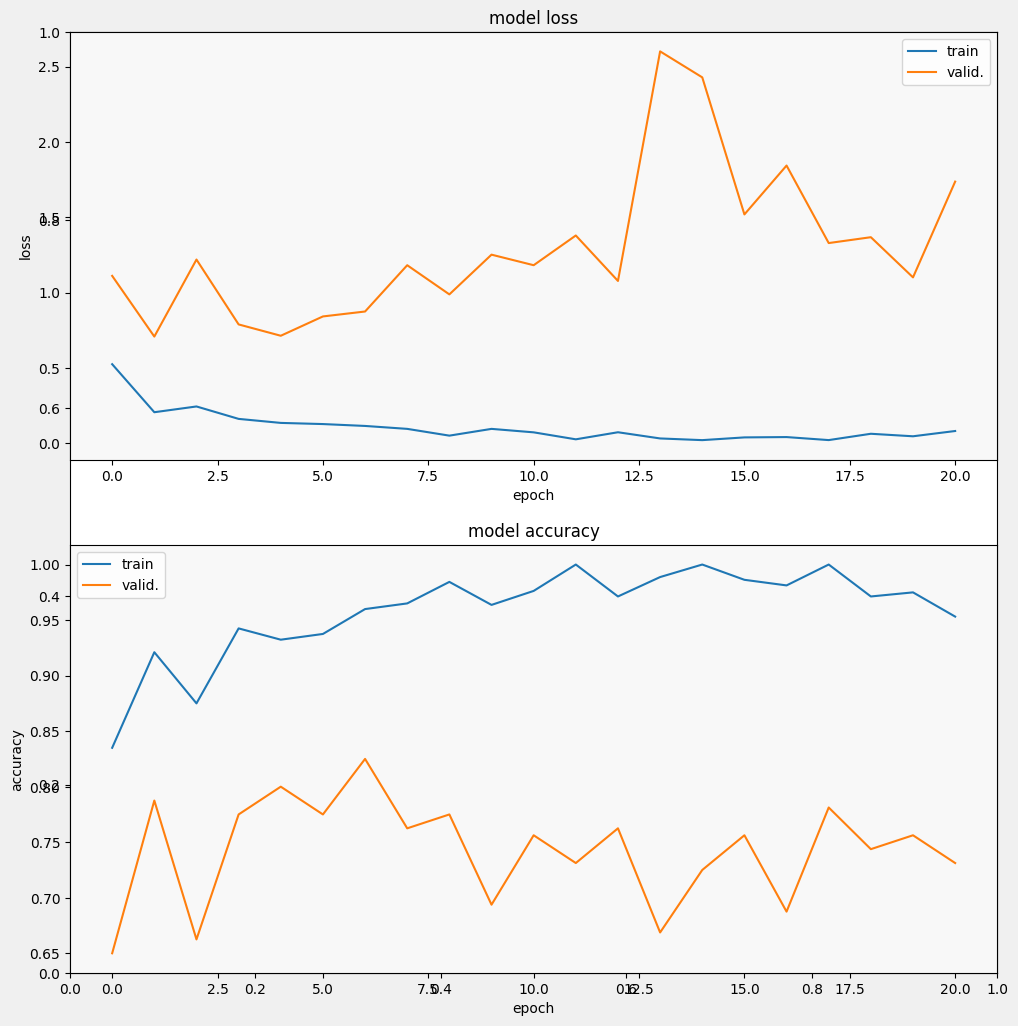

In [22]:
display_training_curves(history.history['loss'], history.history['val_loss'], 'loss', 211)
display_training_curves(history.history['accuracy'], history.history['val_accuracy'], 'accuracy', 212)

# Wrapping Up

Remember to **share this notebook and the writeup with your instructor** and submit a link to it in Brightspace.